# Spam Link Detection System using NLP

## Project Overview

We want to implement a system that is able to automatically detect whether a web page contains spam or not based on its URL. This Natural Language Processing (NLP) project will help identify malicious or unwanted web content by analyzing URL patterns and characteristics.

In this notebook, we will:
1. Load and explore the URL spam dataset
2. Preprocess the links using NLP techniques (tokenization, stopword removal, lemmatization)
3. Build a Support Vector Machine (SVM) classifier with default parameters
4. Optimize the model using hyperparameter tuning
5. Save the trained model for production use

This system can be integrated into web browsers, email filters, or security applications to automatically flag suspicious URLs.

---

## Step 1: Loading the Dataset

The dataset can be found in this project folder under the name `url_spam.csv`. We have downloaded it from the following URL:

**Dataset URL:** https://raw.githubusercontent.com/4GeeksAcademy/NLP-project-tutorial/main/url_spam.csv

**Dataset Location:** `data/raw/url_spam.csv`

This dataset contains URLs labeled as spam or legitimate, which we'll use to train our classification model.

### Import Required Libraries

First, let's import all the necessary libraries for NLP and machine learning:

In [ ]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# NLP libraries
import re
import string
from urllib.parse import urlparse
# Import natural language processing libraries
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Machine learning libraries
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split


# For model persistence
import pickle
import os

# Set style for better visualizations
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

### Load the URL Spam Dataset

Now let's load the dataset and examine its structure:

In [2]:
# Load the URL spam dataset
df = pd.read_csv('../data/raw/url_spam.csv')

In [3]:
# Display dataset shape
df.shape

(2999, 2)

In [4]:
# Display first few rows
df.head()

,url,is_spam
0,https://briefingday.us8.list-manage.com/unsubs...,True
1,https://www.hvper.com/,True
2,https://briefingday.com/m/v4n3i4f3,True
3,https://briefingday.com/n/20200618/m#commentform,False
4,https://briefingday.com/fan,True


In [5]:
# Display dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2999 entries, 0 to 2998
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   url      2999 non-null   object
 1   is_spam  2999 non-null   bool  
dtypes: bool(1), object(1)
memory usage: 26.5+ KB


In [6]:
# Check for missing values
df.isnull().sum()

url        0
is_spam    0
dtype: int64

### Dataset Exploration

Let's explore the distribution of spam vs legitimate URLs and examine some sample URLs:

In [7]:
# Check class distribution
df['is_spam'].value_counts()

is_spam
False    2303
True      696
Name: count, dtype: int64

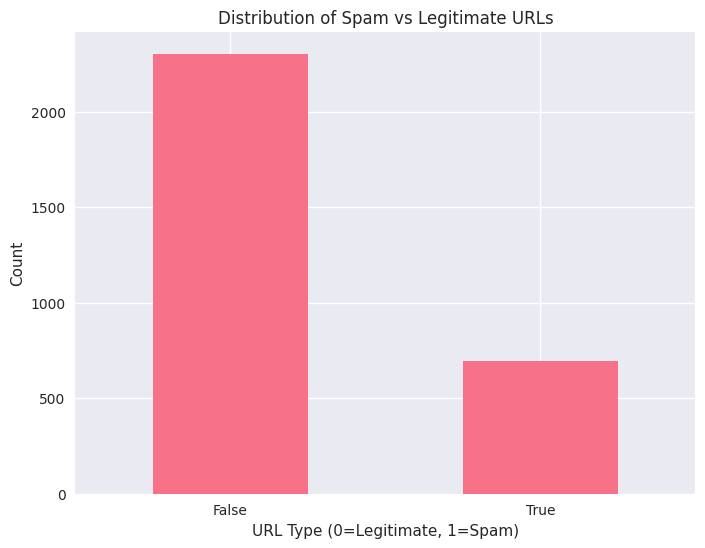

In [8]:
# Visualize class distribution
plt.figure(figsize=(8, 6))
df['is_spam'].value_counts().plot(kind='bar')
plt.title('Distribution of Spam vs Legitimate URLs')
plt.xlabel('URL Type (0=Legitimate, 1=Spam)')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

In [9]:
# Show sample legitimate URLs
df[df['is_spam'] == 0]['url'].head()

3     https://briefingday.com/n/20200618/m#commentform
5    https://www.brookings.edu/interactives/reopeni...
6    https://www.reuters.com/investigates/special-r...
7    https://www.theatlantic.com/magazine/archive/2...
8    https://www.vox.com/2020/6/17/21294680/john-bo...
Name: url, dtype: object

In [10]:
# Show sample spam URLs
df[df['is_spam'] == 1]['url'].head()

0     https://briefingday.us8.list-manage.com/unsubs...
1                                https://www.hvper.com/
2                    https://briefingday.com/m/v4n3i4f3
4                           https://briefingday.com/fan
29                                https://join1440.com/
Name: url, dtype: object

In [11]:
# Analyze URL lengths by class
df['url_length'] = df['url'].str.len()
df.groupby('is_spam')['url_length'].describe()

,count,mean,std,min,25%,50%,75%,max
is_spam,,,,,,,,
False,2303.0,82.128528,34.136308,16.0,56.0,82.0,102.0,269.0
True,696.0,44.816092,20.152029,16.0,33.0,38.0,51.0,135.0


## Step 2: Preprocess the Links

Now we'll transform the URLs to make them compatible with our machine learning model. We'll use various NLP techniques to extract meaningful features from the URLs:

1. **URL Parsing**: Break URLs into components (domain, path, query parameters)
2. **Tokenization**: Split URLs into tokens based on punctuation marks
3. **Text Cleaning**: Remove special characters and normalize text
4. **Feature Extraction**: Create features that can help identify spam patterns

### URL Parsing and Feature Extraction

Let's start by extracting various components and features from the URLs:

In [ ]:
# Basic URL preprocessing function
def preprocess_url(url):
    # Convert to lowercase
    url = url.lower()
    
    # Replace punctuation marks with spaces
    url = re.sub(r'[^\w\s]', ' ', url)
    
    # Remove extra whitespace and normalize
    url = ' '.join(url.split())
    
    return url

In [13]:
# Apply preprocessing to all URLs
df['processed_url'] = df['url'].apply(preprocess_url)

In [14]:
# Display examples of original vs processed URLs
df[['url', 'processed_url']].head()

,url,processed_url
0,https://briefingday.us8.list-manage.com/unsubs...,https briefingday us8 list manage com unsubscribe
1,https://www.hvper.com/,https www hvper com
2,https://briefingday.com/m/v4n3i4f3,https briefingday com m v4n3i4f3
3,https://briefingday.com/n/20200618/m#commentform,https briefingday com n 20200618 m commentform
4,https://briefingday.com/fan,https briefingday com fan


In [ ]:
# Download required NLTK data
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('punkt', quiet=True)

# Initialize English stopwords and lemmatizer
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

In [16]:
# Advanced preprocessing function with stopword removal and lemmatization
def advanced_preprocess_url(url):
    # Basic preprocessing
    url = preprocess_url(url)
    
    # Tokenize the URL
    words = url.split()
    
    # Remove stopwords and lemmatize
    processed_words = []
    for word in words:
        if word.lower() not in stop_words and len(word) > 1:
            lemmatized_word = lemmatizer.lemmatize(word.lower())
            processed_words.append(lemmatized_word)
    
    return ' '.join(processed_words)

In [17]:
# Apply advanced preprocessing to all URLs
df['final_processed_url'] = df['url'].apply(advanced_preprocess_url)

In [18]:
# Compare original, basic processed, and final processed URLs
comparison_df = df[['url', 'processed_url', 'final_processed_url', 'is_spam']].head(10)
comparison_df

,url,processed_url,final_processed_url,is_spam
0,https://briefingday.us8.list-manage.com/unsubs...,https briefingday us8 list manage com unsubscribe,http briefingday us8 list manage com unsubscribe,True
1,https://www.hvper.com/,https www hvper com,http www hvper com,True
2,https://briefingday.com/m/v4n3i4f3,https briefingday com m v4n3i4f3,http briefingday com v4n3i4f3,True
3,https://briefingday.com/n/20200618/m#commentform,https briefingday com n 20200618 m commentform,http briefingday com 20200618 commentform,False
4,https://briefingday.com/fan,https briefingday com fan,http briefingday com fan,True
5,https://www.brookings.edu/interactives/reopeni...,https www brookings edu interactives reopening...,http www brookings edu interactives reopening ...,False
6,https://www.reuters.com/investigates/special-r...,https www reuters com investigates special rep...,http www reuters com investigates special repo...,False
7,https://www.theatlantic.com/magazine/archive/2...,https www theatlantic com magazine archive 202...,http www theatlantic com magazine archive 2020...,False
8,https://www.vox.com/2020/6/17/21294680/john-bo...,https www vox com 2020 6 17 21294680 john bolt...,http www vox com 2020 17 21294680 john bolton ...,False
9,https://www.theguardian.com/travel/2020/jun/18...,https www theguardian com travel 2020 jun 18 e...,http www theguardian com travel 2020 jun 18 en...,False


## Step 3: Data Splitting

Split the preprocessed data into training and testing sets to prepare for machine learning model training and evaluation.

In [ ]:
X = df['final_processed_url']
y = df['is_spam']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Display dataset shapes
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((2399,), (600,), (2399,), (600,))